In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
df = pd.read_csv(r"/content/drive/MyDrive/data/cleaned_data_UK.csv")

In [65]:
primary = "#2563EB"
secondary = "#3B82F6"
accent = "#60A5FA"
light_blue1 = "#93C5FD"
light_blue2 = "#BFDBFE"
background = "#F8FAFC"
card_bg = "#FFFFFF"
text_color = "#1E293B"

# **1- What are the most frequent reasons for delay or cancellation?**

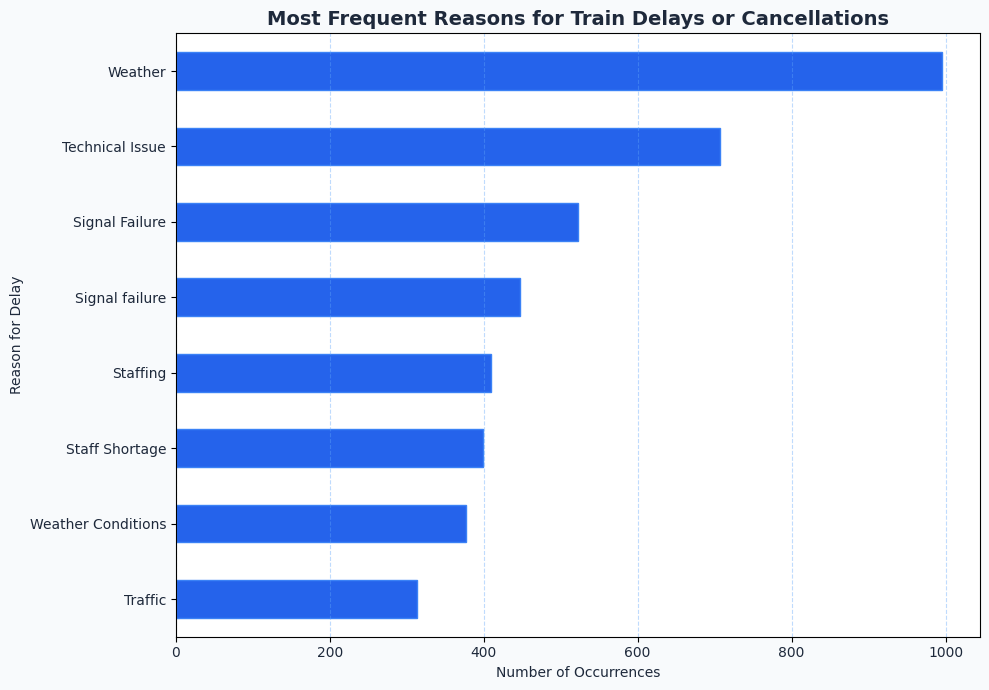

In [20]:
delays = df[df['Reason for Delay'] != 'No delay']
reason_counts = delays['Reason for Delay'].value_counts()
plt.figure(figsize=(10, 7), facecolor=background)
ax = reason_counts.plot(kind='barh',color=primary,edgecolor=secondary)
plt.title("Most Frequent Reasons for Train Delays or Cancellations",color=text_color, fontsize=14, weight='bold')
plt.xlabel("Number of Occurrences", color=text_color)
plt.ylabel("Reason for Delay", color=text_color)
ax.set_facecolor(card_bg)
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.4, color=accent)
plt.xticks(color=text_color)
plt.yticks(color=text_color)
plt.tight_layout()
plt.show()

# **2- Which stations experience delays/cancellations most frequently?**

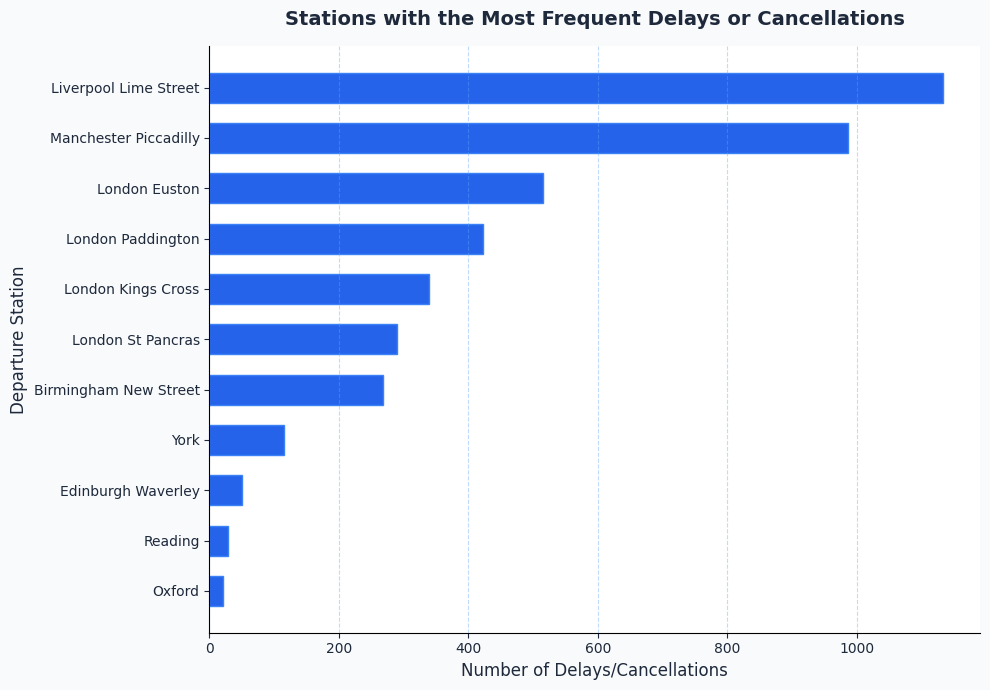

In [19]:
problematic = df[(df["Journey Status"] != "On Time") | (df["Reason for Delay"] != "No delay")]
station_counts = problematic["Departure Station"].value_counts()
fig, ax = plt.subplots(figsize=(10, 7), facecolor=background)
ax.set_facecolor(card_bg)
bars = ax.barh(station_counts.index, station_counts.values,color=primary, edgecolor=secondary, height=0.6)
ax.set_title("Stations with the Most Frequent Delays or Cancellations",fontsize=14, fontweight="bold", color=text_color, pad=15)
ax.set_xlabel("Number of Delays/Cancellations", fontsize=12, color=text_color)
ax.set_ylabel("Departure Station", fontsize=12, color=text_color)
ax.invert_yaxis()
ax.grid(axis="x", linestyle="--", alpha=0.4, color=accent)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="x", colors=text_color)
ax.tick_params(axis="y", colors=text_color)
plt.tight_layout()
plt.show()

# **3- What is the average delay duration per reason and per station?**

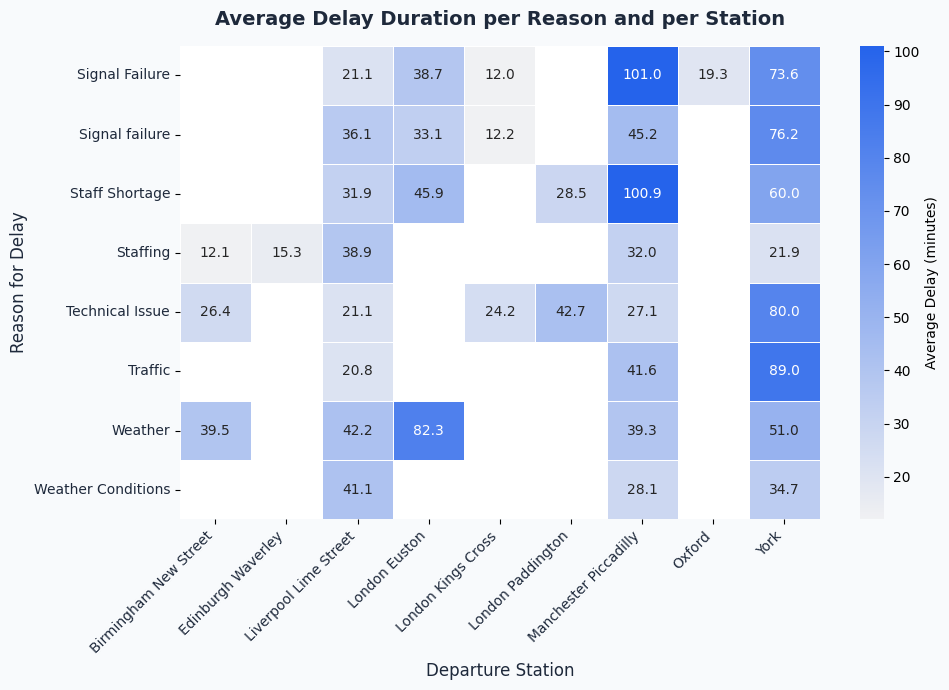

In [18]:
df["Arrival Time"] = pd.to_datetime(df["Arrival Time"], format="%H:%M:%S")
df["Actual Arrival Time"] = pd.to_datetime(df["Actual Arrival Time"], format="%H:%M:%S")
df["Delay_Minutes"] = (df["Actual Arrival Time"] - df["Arrival Time"]).dt.total_seconds() / 60
df["Delay_Minutes"] = df["Delay_Minutes"].clip(lower=0)
delayed = df[df["Delay_Minutes"] > 0]
avg_delay = delayed.groupby(["Reason for Delay", "Departure Station"])["Delay_Minutes"].mean().reset_index()
pivot_table = avg_delay.pivot(index="Reason for Delay", columns="Departure Station", values="Delay_Minutes")

plt.figure(figsize=(10, 7), facecolor=background)
sns.heatmap(pivot_table,annot=True, fmt=".1f", cmap=sns.light_palette(primary, as_cmap=True),
    linewidths=0.5, cbar_kws={"label": "Average Delay (minutes)"}
)
plt.title("Average Delay Duration per Reason and per Station", fontsize=14, fontweight="bold", color=text_color, pad=15)
plt.xlabel("Departure Station", fontsize=12, color=text_color)
plt.ylabel("Reason for Delay", fontsize=12, color=text_color)
plt.xticks(rotation=45, ha="right", color=text_color)
plt.yticks(rotation=0, color=text_color)
plt.tight_layout()
plt.show()

# **4- Do delays/cancellations occur more at specific times of day or on certain days of the week/month?**

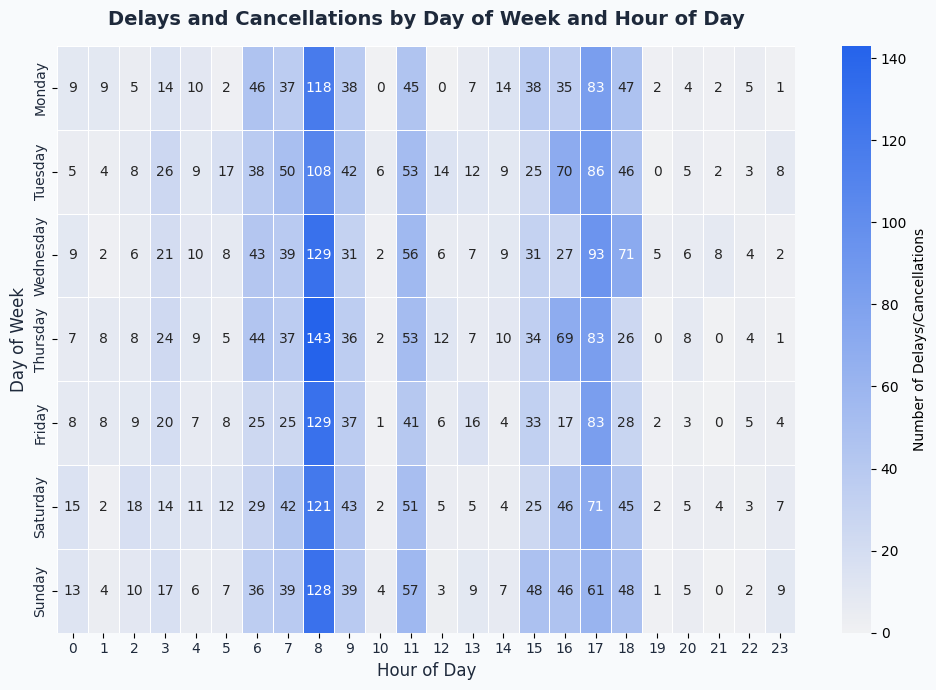

In [23]:
df["Date of Journey"] = pd.to_datetime(df["Date of Journey"])
df["Departure Time"] = pd.to_datetime(df["Departure Time"], format="%H:%M:%S", errors="coerce")
df["DayOfWeek"] = df["Date of Journey"].dt.day_name()
df["Month"] = df["Date of Journey"].dt.strftime("%B")
df["Hour"] = df["Departure Time"].dt.hour
problems = df[(df["Journey Status"] != "On Time") | (df["Reason for Delay"] != "No delay")]
delay_pattern = problems.groupby(["DayOfWeek", "Hour"]).size().reset_index(name="Count")
days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
delay_pattern["DayOfWeek"] = pd.Categorical(delay_pattern["DayOfWeek"], categories=days_order, ordered=True)
pivot = delay_pattern.pivot(index="DayOfWeek", columns="Hour", values="Count").fillna(0)
plt.figure(figsize=(10, 7), facecolor=background)
sns.heatmap(
    pivot,
    cmap=sns.light_palette(primary, as_cmap=True),
    annot=True, fmt=".0f",
    linewidths=0.5,
    cbar_kws={"label": "Number of Delays/Cancellations"}
)
plt.title("Delays and Cancellations by Day of Week and Hour of Day",
          fontsize=14, fontweight="bold", color=text_color, pad=15)
plt.xlabel("Hour of Day", fontsize=12, color=text_color)
plt.ylabel("Day of Week", fontsize=12, color=text_color)
plt.xticks(color=text_color)
plt.yticks(color=text_color)
plt.tight_layout()
plt.show()

# **5- Are certain routes (Departure–Arrival pairs) more prone to delays/cancellations?**

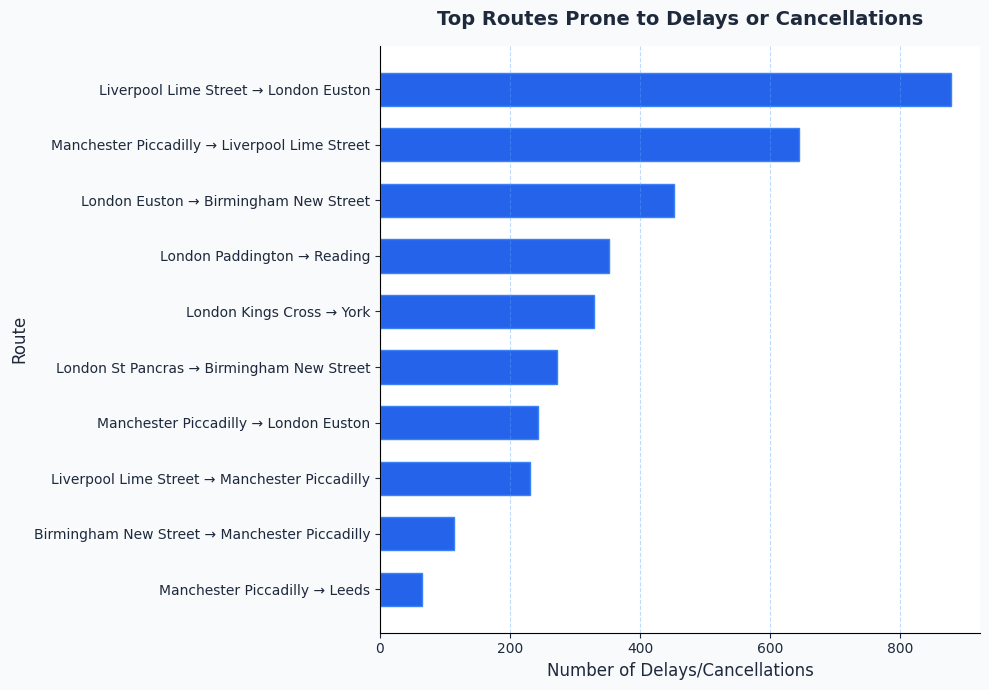

In [24]:

df["Route"] = df["Departure Station"] + " → " + df["Arrival Destination"]
problems = df[(df["Journey Status"] != "On Time") | (df["Reason for Delay"] != "No delay")]
route_counts = problems["Route"].value_counts().head(10)
fig, ax = plt.subplots(figsize=(10,7), facecolor=background)
ax.set_facecolor(card_bg)
bars = ax.barh(route_counts.index, route_counts.values,
               color=primary, edgecolor=secondary, height=0.6)
ax.set_title("Top Routes Prone to Delays or Cancellations",
             fontsize=14, fontweight="bold", color=text_color, pad=15)
ax.set_xlabel("Number of Delays/Cancellations", fontsize=12, color=text_color)
ax.set_ylabel("Route", fontsize=12, color=text_color)
ax.invert_yaxis()
ax.grid(axis="x", linestyle="--", alpha=0.4, color=accent)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="x", colors=text_color)
ax.tick_params(axis="y", colors=text_color)
plt.tight_layout()
plt.show()

# **6- How much revenue loss is caused by delays and cancellations (refunds, compensation)?**

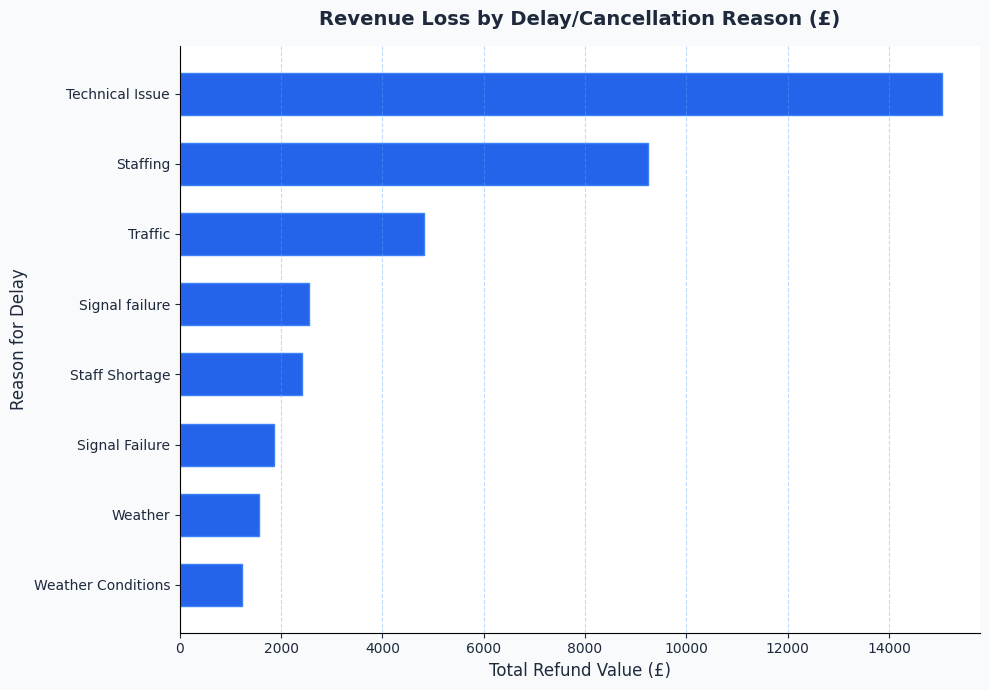

In [26]:
total_revenue = df["Price"].sum()
refunds = df[df["Refund Request"].str.lower() == "yes"]
revenue_loss = refunds["Price"].sum()
loss_by_reason = refunds.groupby("Reason for Delay")["Price"].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 7), facecolor=background)
ax.set_facecolor(card_bg)
bars = ax.barh(loss_by_reason.index, loss_by_reason.values,
               color=primary, edgecolor=secondary, height=0.6)
ax.set_title("Revenue Loss by Delay/Cancellation Reason (£)",
             fontsize=14, fontweight="bold", color=text_color, pad=15)
ax.set_xlabel("Total Refund Value (£)", fontsize=12, color=text_color)
ax.set_ylabel("Reason for Delay", fontsize=12, color=text_color)
ax.invert_yaxis()
ax.grid(axis="x", linestyle="--", alpha=0.4, color=accent)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="x", colors=text_color)
ax.tick_params(axis="y", colors=text_color)
plt.tight_layout()
plt.show()

# **7- Which ticket classes/types are most affected by delays (Standard, Advance, etc.)?**

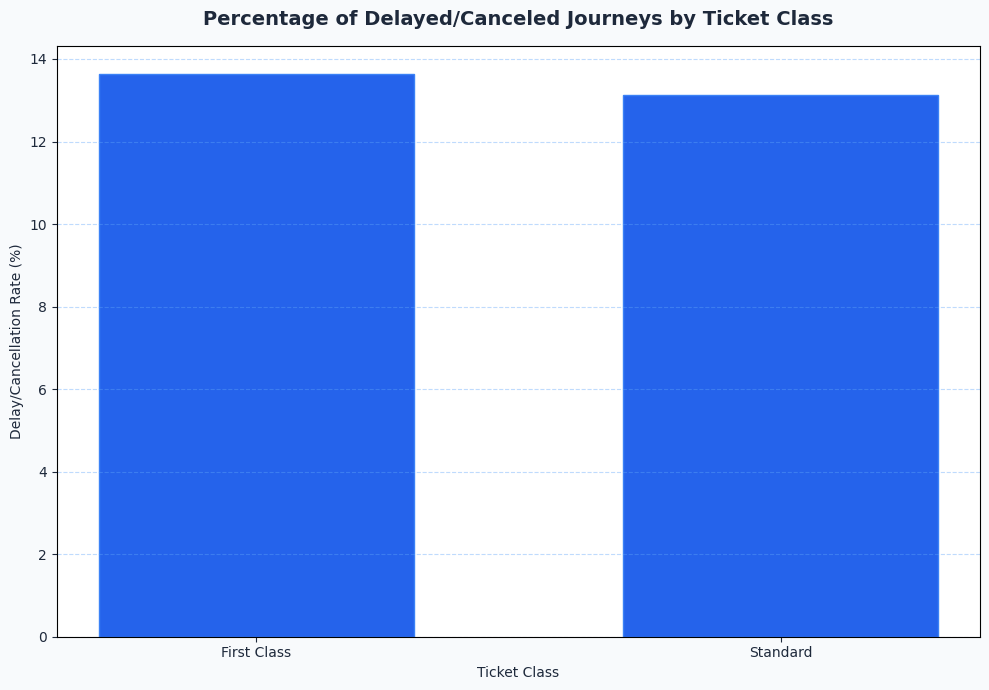

In [28]:
df["Journey Status"] = df["Journey Status"].str.lower()
df["Ticket Class"] = df["Ticket Class"].fillna("Unknown")
df["Ticket Type"] = df["Ticket Type"].fillna("Unknown")
delay_mask = df["Journey Status"].isin(["delayed", "cancelled"])
delays_by_class = df[delay_mask]["Ticket Class"].value_counts()
total_by_class = df["Ticket Class"].value_counts()

delay_percent_class = (delays_by_class / total_by_class * 100).fillna(0).sort_values(ascending=False)
delays_by_type = df[delay_mask]["Ticket Type"].value_counts()
total_by_type = df["Ticket Type"].value_counts()
delay_percent_type = (delays_by_type / total_by_type * 100).fillna(0).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 7), facecolor=background)
ax.set_facecolor(card_bg)
bars = ax.bar(delay_percent_class.index, delay_percent_class.values,
              color=primary, edgecolor=secondary, width=0.6)
ax.set_title("Percentage of Delayed/Canceled Journeys by Ticket Class",
             color=text_color, fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Ticket Class", color=text_color)
ax.set_ylabel("Delay/Cancellation Rate (%)", color=text_color)
ax.grid(axis="y", linestyle="--", alpha=0.4, color=accent)
ax.tick_params(colors=text_color)
plt.tight_layout()
plt.show()

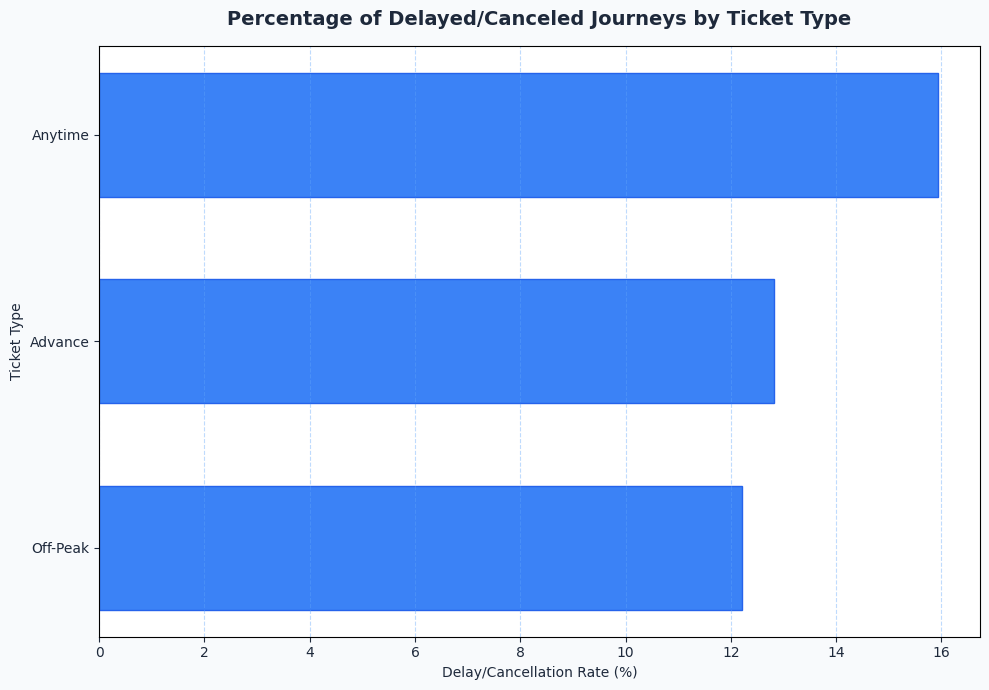

In [29]:
fig, ax = plt.subplots(figsize=(10, 7), facecolor=background)
ax.set_facecolor(card_bg)
bars = ax.barh(delay_percent_type.index, delay_percent_type.values,
               color=secondary, edgecolor=primary, height=0.6)
ax.set_title("Percentage of Delayed/Canceled Journeys by Ticket Type",
             color=text_color, fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Delay/Cancellation Rate (%)", color=text_color)
ax.set_ylabel("Ticket Type", color=text_color)
ax.grid(axis="x", linestyle="--", alpha=0.4, color=accent)
ax.invert_yaxis()
ax.tick_params(colors=text_color)
plt.tight_layout()
plt.show()

# **8- How does the refund request rate vary by reason, station, and route?**

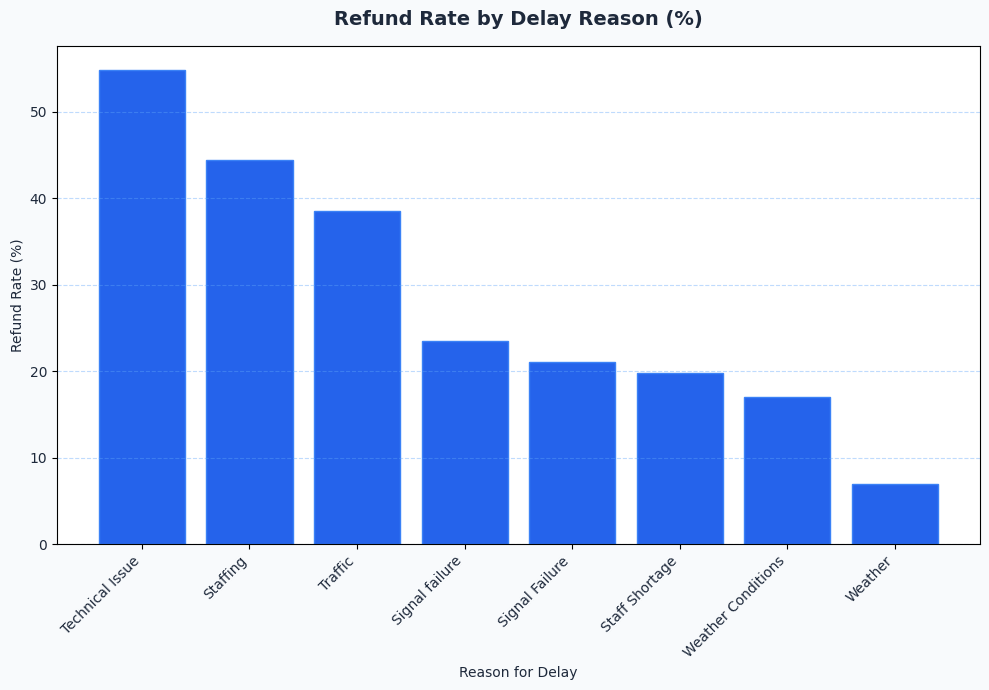

In [36]:
df["Route"] = df["Departure Station"] + " → " + df["Arrival Destination"]
df["Refund Request"] = df["Refund Request"].str.lower()
df_delayed = df[df["Reason for Delay"] != "No delay"]
def refund_rate(group_col):
    grouped = df_delayed.groupby(group_col).agg(
        total_journeys=("Transaction ID", "count"),
        refunds=("Refund Request", lambda x: (x == "yes").sum())
    )
    grouped["Refund_Rate"] = grouped["refunds"] / grouped["total_journeys"] * 100
    return grouped.sort_values("Refund_Rate", ascending=False)
rate_by_reason = refund_rate("Reason for Delay")
plt.figure(figsize=(10,7), facecolor=background)
bars = plt.bar(rate_by_reason.index, rate_by_reason["Refund_Rate"],
               color=primary, edgecolor=secondary)

plt.title("Refund Rate by Delay Reason (%)", fontsize=14, fontweight="bold", color=text_color, pad=15)
plt.ylabel("Refund Rate (%)", color=text_color)
plt.xlabel("Reason for Delay", color=text_color)
plt.xticks(rotation=45, ha="right", color=text_color)
plt.yticks(color=text_color)
plt.grid(axis="y", linestyle="--", alpha=0.4, color=accent)
plt.tight_layout()
plt.show()


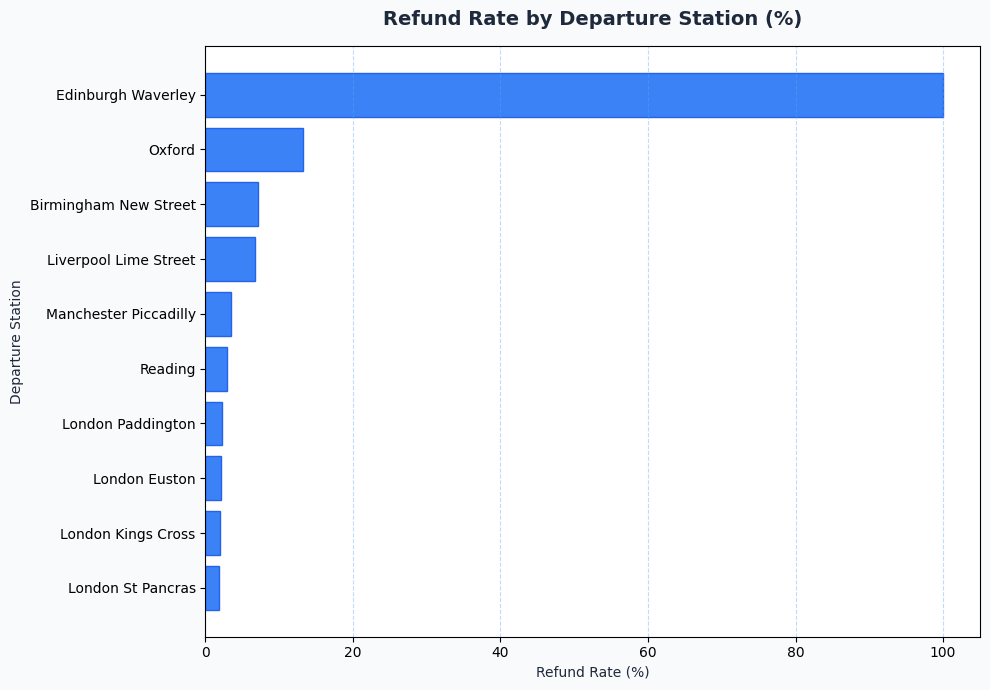

In [32]:
rate_by_station = refund_rate("Departure Station").head(10)
plt.figure(figsize=(10,7), facecolor=background)
bars = plt.barh(rate_by_station.index, rate_by_station["Refund_Rate"],
                color=secondary, edgecolor=primary)
plt.title("Refund Rate by Departure Station (%)", fontsize=14, fontweight="bold", color=text_color, pad=15)
plt.xlabel("Refund Rate (%)", color=text_color)
plt.ylabel("Departure Station", color=text_color)
plt.grid(axis="x", linestyle="--", alpha=0.4, color=accent)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

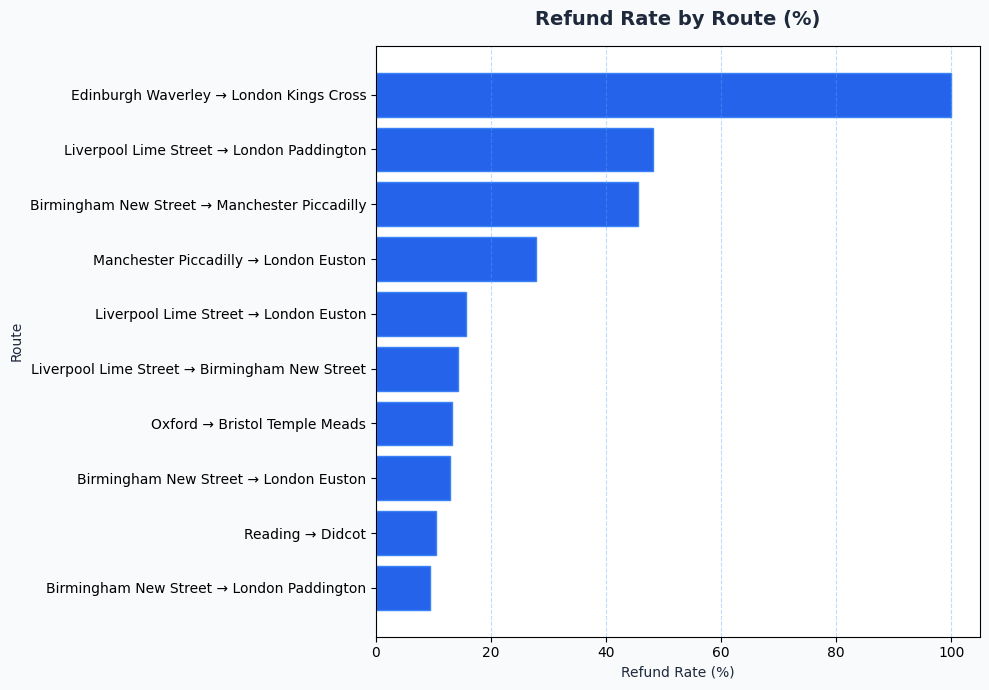

In [34]:
rate_by_route = refund_rate("Route").head(10)
plt.figure(figsize=(10,7), facecolor=background)
bars = plt.barh(rate_by_route.index, rate_by_route["Refund_Rate"],
                color=primary, edgecolor=secondary)
plt.title("Refund Rate by Route (%)", fontsize=14, fontweight="bold", color=text_color, pad=15)
plt.xlabel("Refund Rate (%)", color=text_color)
plt.ylabel("Route", color=text_color)
plt.grid(axis="x", linestyle="--", alpha=0.4, color=accent)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# **9- Which stations are most crowded (highest ticket sales / passenger volume)?**

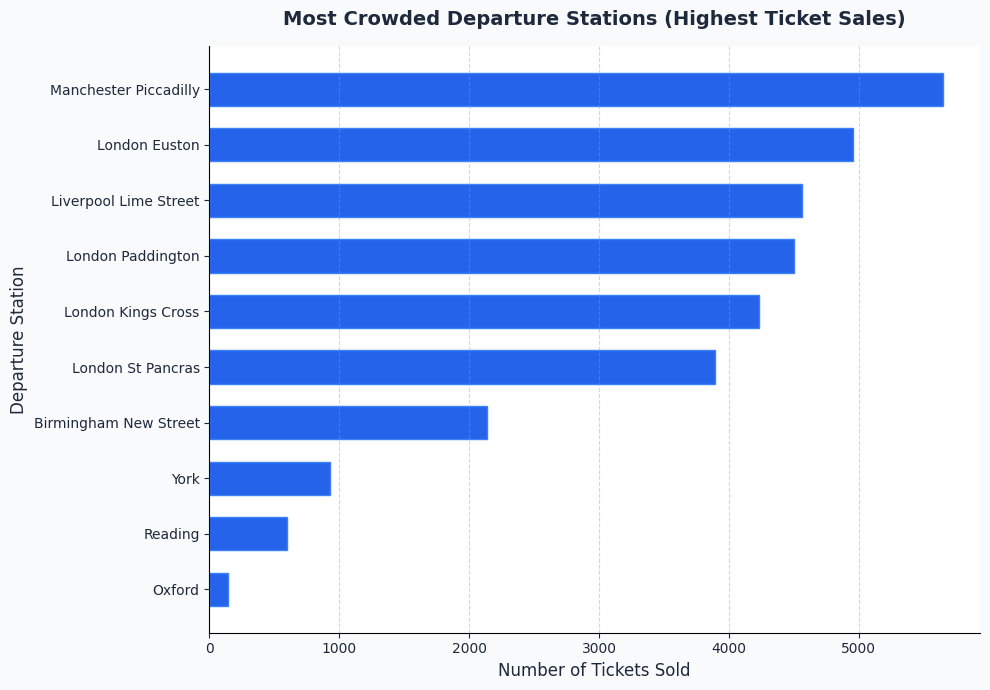

In [38]:
passenger_count = df["Departure Station"].value_counts().head(10)
fig, ax = plt.subplots(figsize=(10,7), facecolor=background)
ax.set_facecolor(card_bg)
bars = ax.barh(passenger_count.index, passenger_count.values,
               color=primary, edgecolor=secondary, height=0.6)
ax.set_title("Most Crowded Departure Stations (Highest Ticket Sales)",
             fontsize=14, fontweight="bold", color=text_color, pad=15)
ax.set_xlabel("Number of Tickets Sold", fontsize=12, color=text_color)
ax.set_ylabel("Departure Station", fontsize=12, color=text_color)
ax.invert_yaxis()
ax.grid(axis="x", linestyle="--", alpha=0.4, color=accent)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="x", colors=text_color)
ax.tick_params(axis="y", colors=text_color)
plt.tight_layout()
plt.show()


# **10- Which stations and routes generate the highest revenue?**

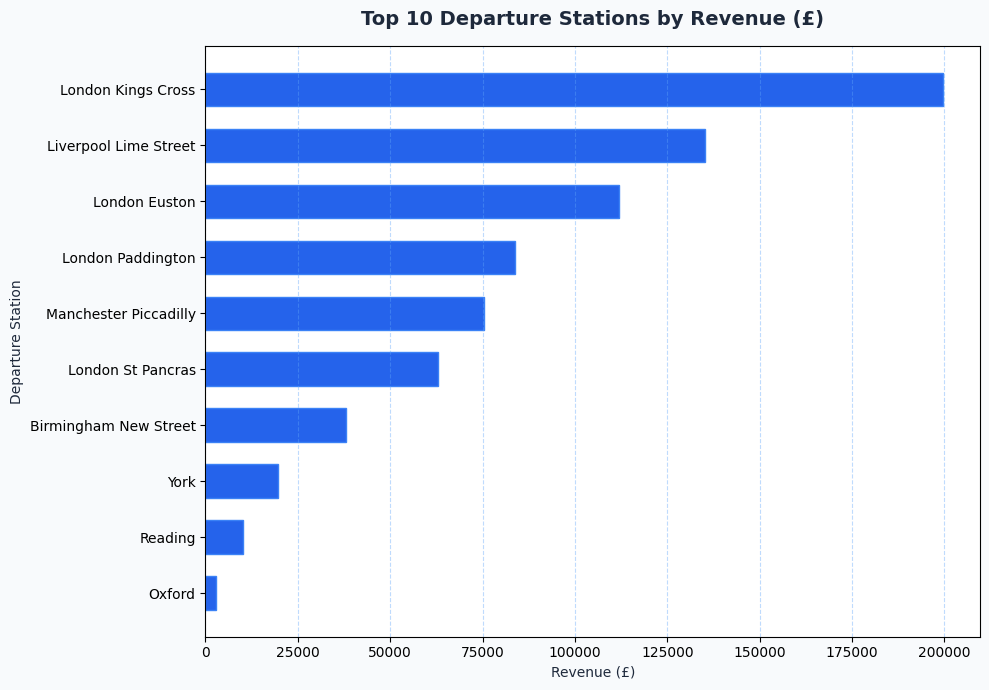

In [39]:
revenue_station = df.groupby("Departure Station")["Price"].sum().sort_values(ascending=False).head(10)
fig, ax = plt.subplots(figsize=(10,7), facecolor=background)
ax.set_facecolor(card_bg)
bars = ax.barh(revenue_station.index, revenue_station.values,
               color=primary, edgecolor=secondary, height=0.6)
ax.set_title("Top 10 Departure Stations by Revenue (£)",
             fontsize=14, fontweight="bold", color=text_color, pad=15)
ax.set_xlabel("Revenue (£)", color=text_color)
ax.set_ylabel("Departure Station", color=text_color)
ax.invert_yaxis()
ax.grid(axis="x", linestyle="--", alpha=0.4, color=accent)
plt.tight_layout()
plt.show()

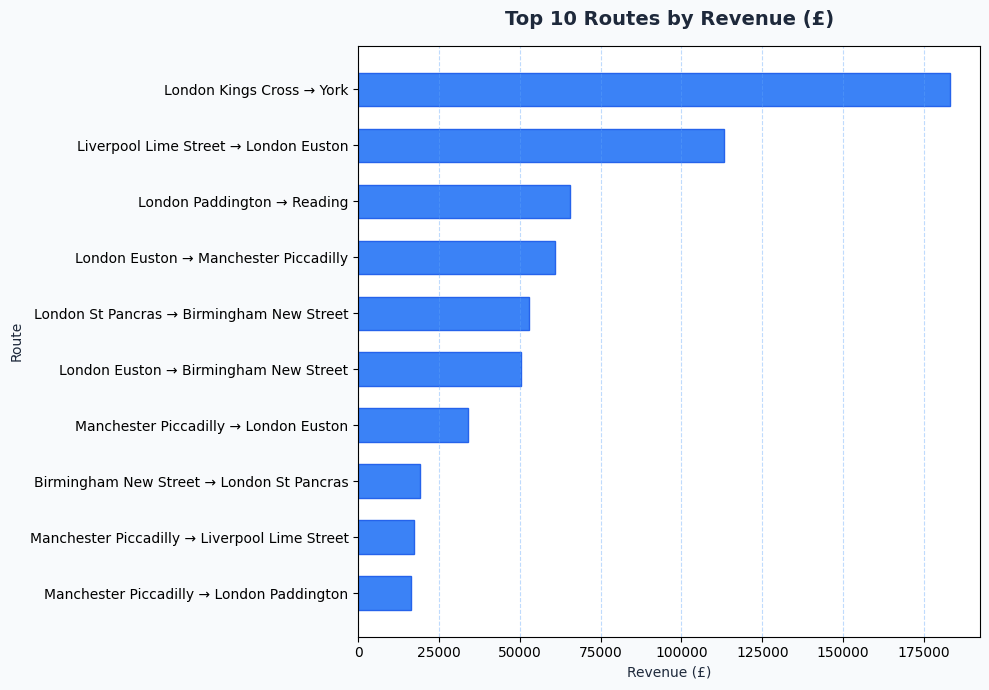

In [41]:
df["Route"] = df["Departure Station"] + " → " + df["Arrival Destination"]
revenue_route = df.groupby("Route")["Price"].sum().sort_values(ascending=False).head(10)
fig, ax = plt.subplots(figsize=(10,7), facecolor=background)
ax.set_facecolor(card_bg)
bars = ax.barh(revenue_route.index, revenue_route.values,
               color=secondary, edgecolor=primary, height=0.6)
ax.set_title("Top 10 Routes by Revenue (£)",
             fontsize=14, fontweight="bold", color=text_color, pad=15)
ax.set_xlabel("Revenue (£)", color=text_color)
ax.set_ylabel("Route", color=text_color)
ax.invert_yaxis()
ax.grid(axis="x", linestyle="--", alpha=0.4, color=accent)
plt.tight_layout()
plt.show()

# **11- What is the most sold ticket type and ticket class?**

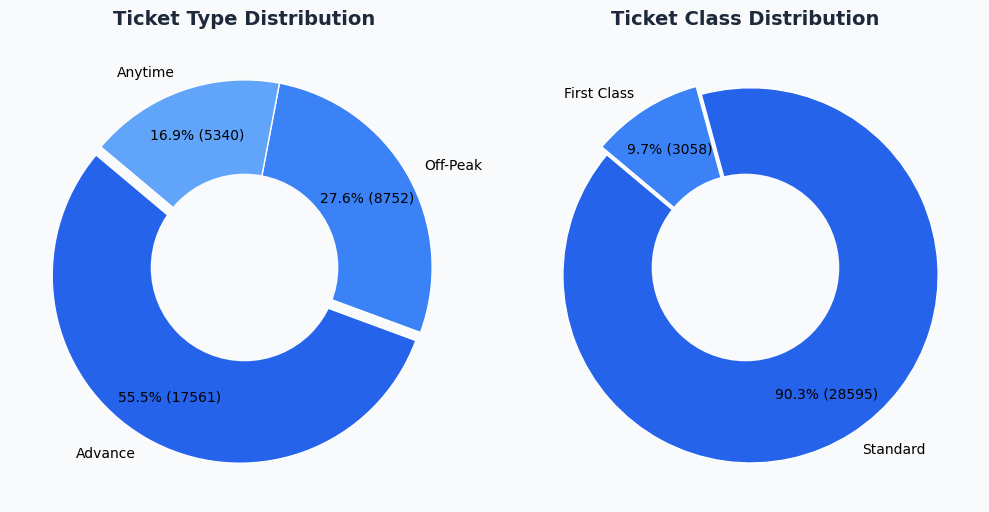

In [52]:
df["Ticket Type"] = df["Ticket Type"].fillna("Unknown")
df["Ticket Class"] = df["Ticket Class"].fillna("Unknown")

type_counts = df["Ticket Type"].value_counts()
class_counts = df["Ticket Class"].value_counts()

colors_type = [primary, secondary, accent, light_blue1, light_blue2][:len(type_counts)]
colors_class = [primary, secondary, accent, light_blue1, light_blue2][:len(class_counts)]

fig, axes = plt.subplots(1, 2, figsize=(10,7), facecolor=background)

axes[0].pie(type_counts, labels=type_counts.index, autopct=lambda p: f"{p:.1f}% ({int(p*sum(type_counts)/100)})",
            startangle=140, colors=colors_type, wedgeprops={'edgecolor': card_bg, 'linewidth':1},
            pctdistance=0.75, explode=[0.05 if i==0 else 0 for i in range(len(type_counts))])
centre_circle = plt.Circle((0,0),0.50,fc=background)
axes[0].add_artist(centre_circle)
axes[0].set_title("Ticket Type Distribution", fontsize=14, fontweight="bold", color=text_color)

axes[1].pie(class_counts, labels=class_counts.index, autopct=lambda p: f"{p:.1f}% ({int(p*sum(class_counts)/100)})",
            startangle=140, colors=colors_class, wedgeprops={'edgecolor': card_bg, 'linewidth':1},
            pctdistance=0.75, explode=[0.05 if i==0 else 0 for i in range(len(class_counts))])
centre_circle2 = plt.Circle((0,0),0.50,fc=background)
axes[1].add_artist(centre_circle2)
axes[1].set_title("Ticket Class Distribution", fontsize=14, fontweight="bold", color=text_color)
plt.tight_layout()
plt.show()


# **12- What is the distribution of payment methods (online vs station, card vs cash) — does this impact refunds or cancellations?**

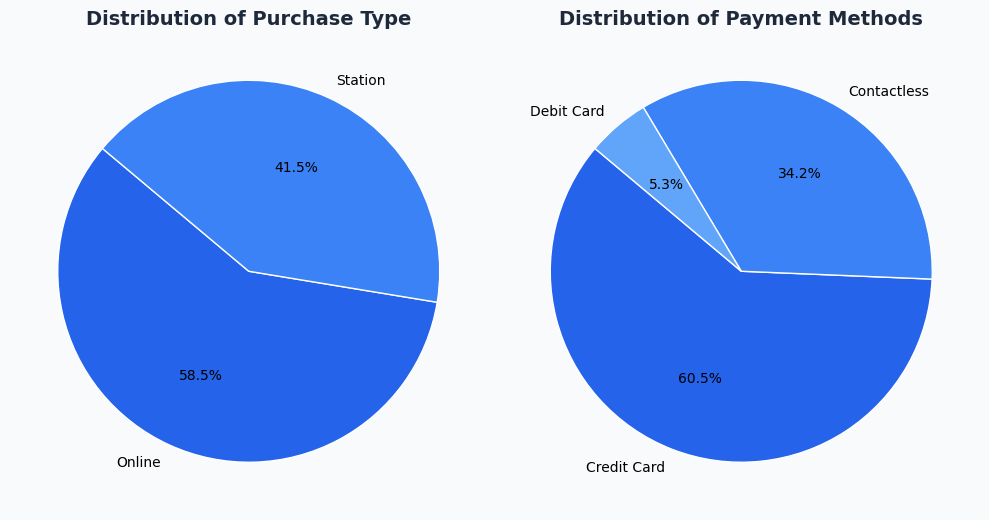

In [56]:
df["Purchase Type"] = df["Purchase Type"].fillna("Unknown")
df["Payment Method"] = df["Payment Method"].fillna("Unknown")
df["Refund Request"] = df["Refund Request"].str.lower()
df["Journey Status"] = df["Journey Status"].str.lower()
purchase_counts = df["Purchase Type"].value_counts()
payment_counts = df["Payment Method"].value_counts()
colors_purchase = [primary, secondary][:len(purchase_counts)]
colors_payment = [primary, secondary, accent, light_blue1, light_blue2][:len(payment_counts)]

fig, axes = plt.subplots(1, 2, figsize=(10,7), facecolor=background)

axes[0].pie(purchase_counts, labels=purchase_counts.index, autopct="%1.1f%%",
            startangle=140, colors=colors_purchase, wedgeprops={'edgecolor': card_bg})
axes[0].set_title("Distribution of Purchase Type", fontsize=14, fontweight="bold", color=text_color)

axes[1].pie(payment_counts, labels=payment_counts.index, autopct="%1.1f%%",
            startangle=140, colors=colors_payment, wedgeprops={'edgecolor': card_bg})
axes[1].set_title("Distribution of Payment Methods", fontsize=14, fontweight="bold", color=text_color)
plt.tight_layout()
plt.show()


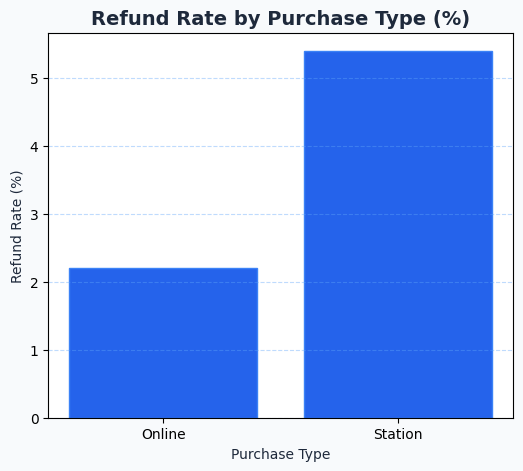

In [58]:
refund_rate_purchase = df.groupby("Purchase Type").agg(
    total_journeys=("Transaction ID", "count"),
    refunds=("Refund Request", lambda x: (x == "yes").sum())
)
refund_rate_purchase["Refund_Rate"] = refund_rate_purchase["refunds"] / refund_rate_purchase["total_journeys"] * 100

plt.figure(figsize=(6,5), facecolor=background)
bars = plt.bar(refund_rate_purchase.index, refund_rate_purchase["Refund_Rate"],
               color=primary, edgecolor=secondary)
plt.title("Refund Rate by Purchase Type (%)", fontsize=14, fontweight="bold", color=text_color)
plt.ylabel("Refund Rate (%)", color=text_color)
plt.xlabel("Purchase Type", color=text_color)
plt.grid(axis="y", linestyle="--", alpha=0.4, color=accent)

plt.show()

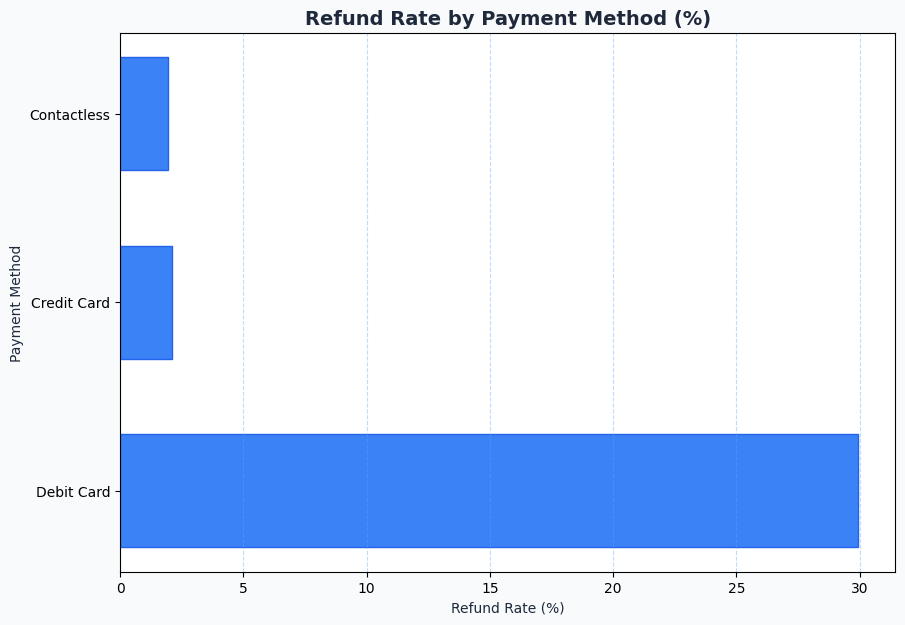

In [61]:
refund_rate_payment = df.groupby("Payment Method").agg(
    total_journeys=("Transaction ID", "count"),
    refunds=("Refund Request", lambda x: (x == "yes").sum())
)
refund_rate_payment["Refund_Rate"] = refund_rate_payment["refunds"] / refund_rate_payment["total_journeys"] * 100

plt.figure(figsize=(10,7), facecolor=background)
bars = plt.barh(refund_rate_payment.index, refund_rate_payment["Refund_Rate"],
                color=secondary, edgecolor=primary, height=0.6)
plt.title("Refund Rate by Payment Method (%)", fontsize=14, fontweight="bold", color=text_color)
plt.xlabel("Refund Rate (%)", color=text_color)
plt.ylabel("Payment Method", color=text_color)
plt.grid(axis="x", linestyle="--", alpha=0.4, color=accent)
plt.gca().invert_yaxis()
plt.show()


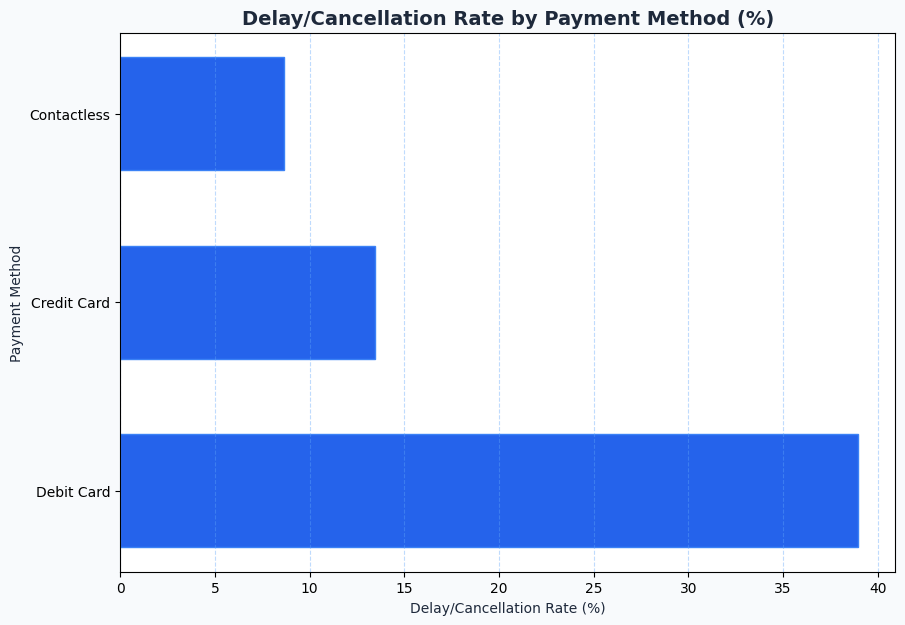

In [63]:
delay_mask = df["Journey Status"].isin(["delayed", "cancelled"])
delay_rate_payment = df.groupby("Payment Method").agg(
    total_journeys=("Transaction ID", "count"),
    delays=("Journey Status", lambda x: x.isin(["delayed","cancelled"]).sum())
)
delay_rate_payment["Delay_Rate"] = delay_rate_payment["delays"] / delay_rate_payment["total_journeys"] * 100

plt.figure(figsize=(10,7), facecolor=background)
bars = plt.barh(delay_rate_payment.index, delay_rate_payment["Delay_Rate"],
                color=primary, edgecolor=secondary, height=0.6)
plt.title("Delay/Cancellation Rate by Payment Method (%)", fontsize=14, fontweight="bold", color=text_color)
plt.xlabel("Delay/Cancellation Rate (%)", color=text_color)
plt.ylabel("Payment Method", color=text_color)
plt.grid(axis="x", linestyle="--", alpha=0.4, color=accent)
plt.gca().invert_yaxis()
plt.show()